In [2]:
import numpy as np
import pandas as pd
import warnings
import mne
import matplotlib.pyplot as plt
mne.set_log_level('ERROR')
warnings.filterwarnings("ignore")

### **Funciones auxiliares**

In [3]:
def export_cleaned_csv(df, filename):
    """
    Exporta a archivo CSV Para inspeccionar la data en formato tabular
    """
    #pattern_cols = [col for col in df.columns if col.count('_') == 2]
    manual_cols = [
        'SelectedRow', 'SelectedColumn', 'PhaseInSequence',
        'StimulusCode', 'FakeFeedback', 'DisplayResults']
    cols_to_drop = list(set(pattern_cols + manual_cols))
    df_cleaned = df.drop(columns=cols_to_drop, errors='ignore')       # Eliminar columnas del DataFrame
    df_cleaned[df_cleaned.select_dtypes(include='number').columns] = df_cleaned.select_dtypes(include='number').round(1) # Redondear
    df_cleaned.to_csv(filename, index=False, sep=";") # Exportar a CSV

#export_cleaned_csv(df, "F_03_SE001_CBCol_Train01_cleaned.csv")

In [4]:
def extract_sequence(array):
    changes = np.insert(array[1:] != array[:-1], 0, True)
    result = array[(array != 0) & changes]
    return result

In [5]:
def get_flashing_characters(df, index):
    """
    Devuelve una lista con los nombres de las columnas tipo X_Y_Z 
    que tienen el valor activo (por defecto: 1000000.0) en el índice dado.
    """
    char_cols = [col for col in df.columns if col.count('_') == 2]        # Columnas de formato X_Y_Z
    row_values = df.loc[index, char_cols]
    flashing_chars = row_values[row_values == 1000000.0].index.tolist()
    return flashing_chars

In [6]:
def get_flashing_characters_batch(df, indices):
    """
    Para cada índice en 'indices', devuelve un diccionario donde:
    - clave = índice,
    - valor = lista de caracteres tipo X_Y_Z con valor activo.
    """
    result = {}
    for idx in indices:
        chars = get_flashing_characters(df, idx)
        result[idx] = chars
    return result

In [7]:
def split_event_indices(event_indices, group_size):
    """
    Divide la lista de índices en sublistas de tamaño fijo.
    Retorna un diccionario con claves 'subset1', 'subset2', ..., 
    y valores que son listas de índices.
    """
    subsets = {}
    total = len(event_indices)
    num_groups = (total + group_size - 1) // group_size  # redondeo hacia arriba

    for i in range(num_groups):
        start = i * group_size
        end = min((i + 1) * group_size, total)
        subset_name = f"subset{i+1}"
        subsets[subset_name] = event_indices[start:end]

    return subsets
#resultados = get_flashing_characters_batch(df, subset2)

In [8]:
def obtener_elemento_mas_repetido_por_subset(all_resultados):
    """
    Para cada subset del diccionario all_resultados, encuentra el elemento más repetido.
    Args: all_resultados (dict): Diccionario de la forma {'subsetX': {indice: [lista_de_elementos]}}
    Returns:dict: Diccionario {'subsetX': 'elemento_mas_repetido'}
    """
    resumen = {}
    for subset_name, resultados in all_resultados.items():
        # Aplanar todas las listas del subset en un único array
        elementos = [elem for lista in resultados.values() for elem in lista]
        if elementos:  # Verifica que no esté vacío
            array_np = np.array(elementos)
            valores, conteos = np.unique(array_np, return_counts=True)
            mas_repetido = valores[np.argmax(conteos)]
            resumen[subset_name] = mas_repetido
        else:
            resumen[subset_name] = None  # Por si no hay datos en ese subset
    return resumen

In [9]:
def decode_sequence(index_sequence, grid):
    return ''.join(grid[i - 1] for i in index_sequence if 1 <= i <= len(grid))

### **1. Columnas del dataset**

Index(['time', 'EEG_F3', 'EEG_Fz', 'EEG_F4', 'EEG_T7', 'EEG_C3', 'EEG_Cz',
       'EEG_C4', 'EEG_T8', 'EEG_CP3', 'EEG_CP4', 'EEG_P3', 'EEG_Pz', 'EEG_P4',
       'EEG_PO7', 'EEG_PO8', 'EEG_Oz', 'A_1_1', 'B_1_2', 'C_1_3', 'D_1_4',
       'E_1_5', 'F_1_6', 'G_2_1', 'H_2_2', 'I_2_3', 'J_2_4', 'K_2_5', 'L_2_6',
       'M_3_1', 'N_3_2', 'O_3_3', 'P_3_4', 'Q_3_5', 'R_3_6', 'S_4_1', 'T_4_2',
       'U_4_3', 'V_4_4', 'W_4_5', 'X_4_6', 'Y_5_1', 'Z_5_2', 'Sp_5_3', '1_5_4',
       '2_5_5', '3_5_6', '4_6_1', '5_6_2', '6_6_3', '7_6_4', '8_6_5', '9_6_6',
       'StimulusType', 'SelectedTarget', 'SelectedRow', 'SelectedColumn',
       'PhaseInSequence', 'StimulusBegin', 'StimulusCode', 'CurrentTarget',
       'FakeFeedback', 'DisplayResults'],
      dtype='object')
StimulusBegin
0.0          49760
1000000.0     6048
Name: count, dtype: int64


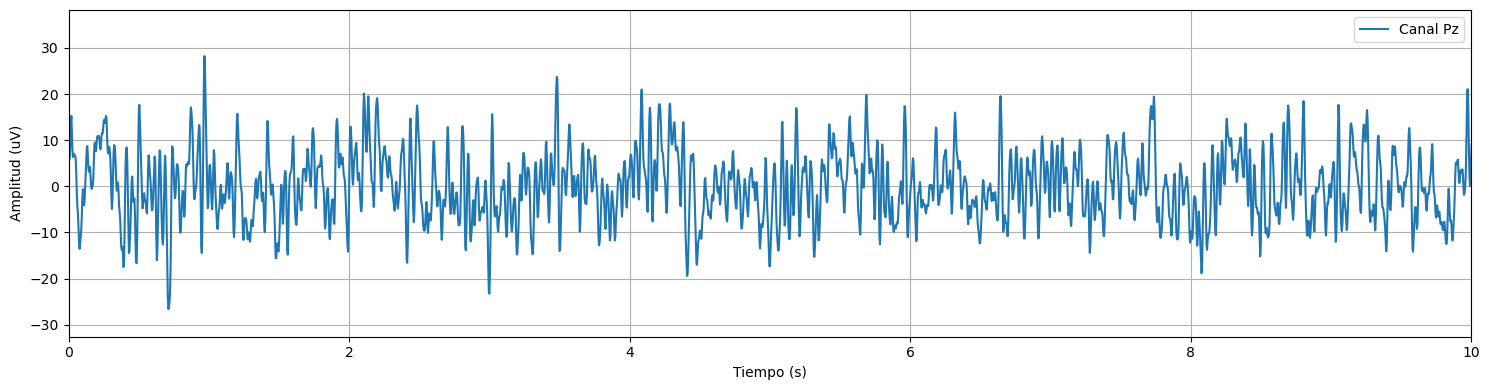

In [10]:
#edf_file = "./StudyF/F_03/SE001/Test/DynBigram/F_03_SE001_DynBigram_Test01.edf" 
#edf_file = "./StudyF/F_03/SE001/Test/Static/F_03_SE001_Static_Test01.edf"
#edf_file = "./StudyF/F_03/SE001/Test/Dyn/F_03_SE001_Dyn_Test01.edf" 
edf_file = "./StudyF/F_03/SE001/Train/CBCol/F_03_SE001_CBCol_Train01.edf" 

raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
df = raw.to_data_frame()
print(df.columns)
print(df["StimulusBegin"].value_counts())

timex = df['time'].values
eegx_pz = df['EEG_Pz'].values

# 5. Plotear
plt.figure(figsize=(15, 4))
plt.plot(timex, eegx_pz, label='Canal Pz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (uV)')
plt.xlim([0,10])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### **2. Analisis de CurrentTarget (Deseado) y SelectedTarget (Predicho)**

In [11]:
grid_6x6 = [
    'A', 'B', 'C', 'D', 'E', 'F',
    'G', 'H', 'I', 'J', 'K', 'L',
    'M', 'N', 'O', 'P', 'Q', 'R',
    'S', 'T', 'U', 'V', 'W', 'X',
    'Y', 'Z', ' ', '1', '2', '3',
    '4', '5', '6', '7', '8', '9']   # Paradigma

time = df['time'].to_numpy()
current_target = df['CurrentTarget'].to_numpy()
selected_target = df['SelectedTarget'].to_numpy()

current_target = (current_target / 1e6).astype(int)   # Normalizar (Los datos vienen *1e6)
selected_target = (selected_target / 1e6).astype(int)
ct_sequence = extract_sequence(current_target)        # Extraer los valores de Current y Selected Target
st_sequence = extract_sequence(selected_target)
decoded_ct = decode_sequence(ct_sequence, grid_6x6)   # Pasar los valores obtenidos a valores alfanumericos
decoded_st = decode_sequence(st_sequence, grid_6x6)

print("CurrentTarget:", ct_sequence)
print("SelectedTarget:", st_sequence)
print("Palabra deseada (CurrentTarget):", decoded_ct)
print("Palabra predicha (SelectedTarget):", decoded_st)

CurrentTarget: [ 6 21 20 21 18  5]
SelectedTarget: [25 29 13 31 27 29]
Palabra deseada (CurrentTarget): FUTURE
Palabra predicha (SelectedTarget): Y2M4 2


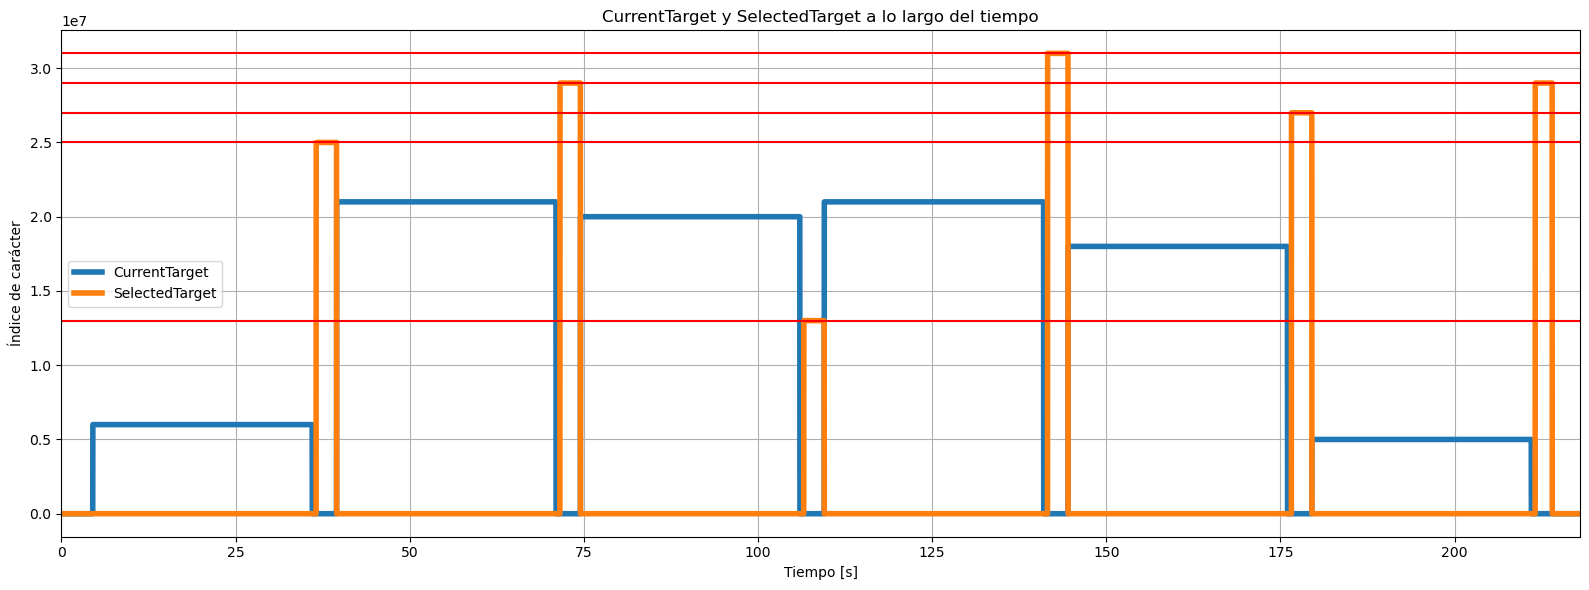

In [12]:
current_target = df['CurrentTarget'].to_numpy()
selected_target = df['SelectedTarget'].to_numpy()
y_lines = [29e6, 25e6, 13e6, 31e6, 27e6]
plt.figure(figsize=(16, 6))
plt.plot(time, current_target, label='CurrentTarget', linewidth=4)
plt.plot(time, selected_target, label='SelectedTarget', linewidth=4)
plt.xlim(0,time[-1])
for y in y_lines:
    plt.axhline(y=y, color='red')

plt.xlabel("Tiempo [s]");plt.ylabel("Índice de carácter");plt.title("CurrentTarget y SelectedTarget a lo largo del tiempo");
plt.legend();plt.grid(True);
plt.tight_layout();plt.show();

### **2. Analisis de StimulusType y StimulusBegin**

Total de eventos detectados: 84
[False False False ... False False False]


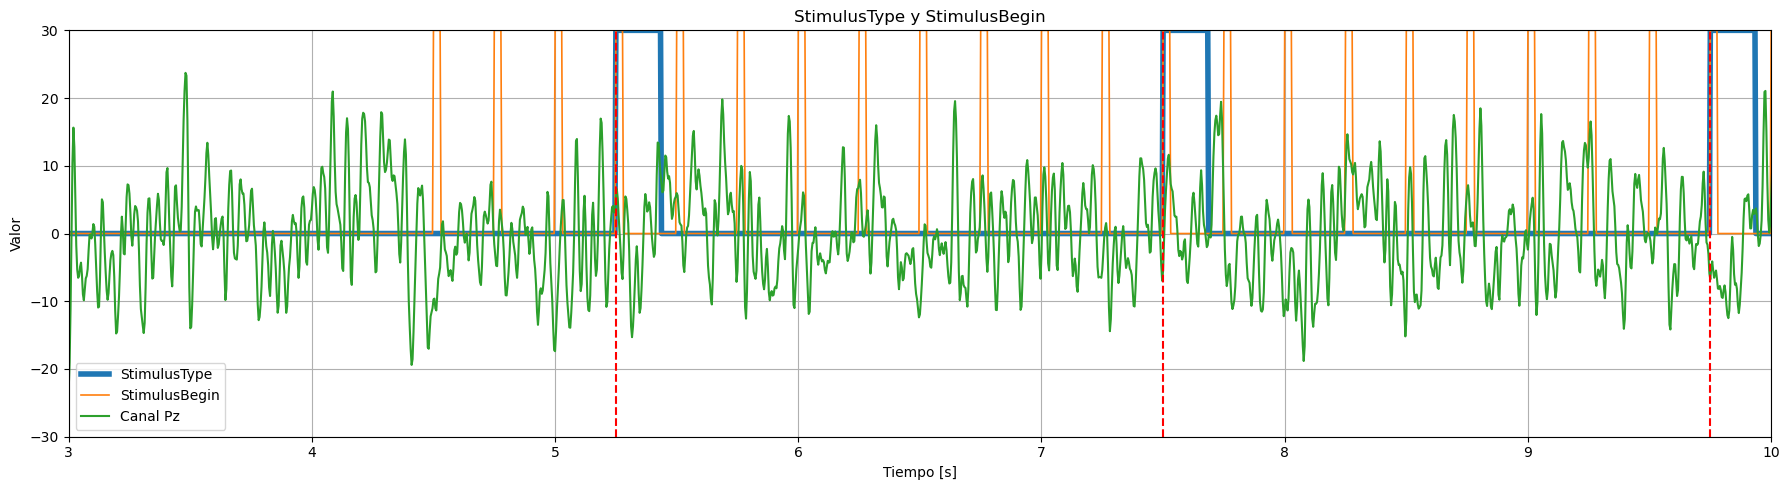

In [19]:
stim_type = (df['StimulusType'].to_numpy() == 1000000.0)
stim_begin = (df['StimulusBegin'].to_numpy() == 1000000.0)
joint_signal = stim_type & stim_begin  # Solo donde ambas condiciones son verdaderas
edges = np.diff(joint_signal, prepend=0)   # Detectar flancos de subida (de 0 a 1)
event_indices = np.where(edges == 1)[0]
print(f"Total de eventos detectados: {len(event_indices)}")
print(stim_type)
plt.figure(figsize=(18, 5))
plt.plot(time, 30*stim_type, label='StimulusType', linewidth=4)
plt.plot(time, 30*stim_begin, label='StimulusBegin', linewidth=1.2)
plt.plot(timex, eegx_pz, label='Canal Pz')
plt.xlabel("Tiempo [s]");plt.ylabel("Valor");plt.title("StimulusType y StimulusBegin");
plt.legend();plt.grid(True);plt.xlim([3, 10]);plt.ylim([-30, 30])
for idx in event_indices:
    plt.axvline(x=time[idx], linestyle='--', color='red')
plt.tight_layout();plt.show();

In [11]:
print(f"Índices de inicio de eventos: {event_indices}")

Índices de inicio de eventos: [ 1344  1920  2496  3008  3520  4288  4864  5248  6016  6528  6976  7616
  8192  8896 10112 10944 11328 11968 12416 13120 13568 14400 14720 15552
 15936 16576 17216 17792 19648 20032 20800 21248 21824 22272 23104 23616
 24256 24576 25408 25792 26496 27072 28032 28736 29312 29888 30592 30976
 31616 32192 32640 33472 33920 34432 35008 35712 37184 37696 38336 38976
 39296 40000 40448 41088 41664 42304 42880 43520 43904 44544 46400 46848
 47552 48192 48704 49216 49728 50432 50944 51648 52288 52736 53440 53824]


In [13]:
char_cols = [col for col in df.columns if col.count('_') == 2]
row = df.loc[1344, char_cols]            # Verifica si al menos una tiene valor 1 en el índice 1344
print("Valores distintos de 0 en esa fila:")
print(row[row != 0])

Valores distintos de 0 en esa fila:
F_1_6    1000000.0
U_4_3    1000000.0
3_5_6    1000000.0
Name: 1344, dtype: float64


In [14]:
subsets = split_event_indices(event_indices, group_size=14)
resultados = get_flashing_characters_batch(df, subsets['subset1'])
all_results = {}
for name, indices in subsets.items():
    results = get_flashing_characters_batch(df, indices)
    all_results[name] = results
    
#for subset_name, subset_data in all_results.items():
#    print(f"\n### {subset_name.upper()} ###")
#    for idx, chars in subset_data.items():
#        t = df.at[idx, 'time']
#        print(f"[{idx}] t = {t:.2f}s → {chars}")

In [15]:
mas_repetidos_por_subset = obtener_elemento_mas_repetido_por_subset(all_results)
for subset, valor in mas_repetidos_por_subset.items():
    print(f"{subset}: {valor}")

subset1: F_1_6
subset2: U_4_3
subset3: T_4_2
subset4: U_4_3
subset5: R_3_6
subset6: E_1_5


### **3. Extracción del Event-Related Potential**

In [16]:
channel = 'EEG_Pz'
eeg_data = df[channel].values
sfreq = int(raw.info['sfreq'])

pre = int(0.2 * sfreq)   # 200 ms antes
post = int(0.8 * sfreq)  # 800 ms después
epoch_len = pre + post
times = np.linspace(-0.2, 0.8, epoch_len)

###   3.1 Usando Flancos de Subida (event _ indices)

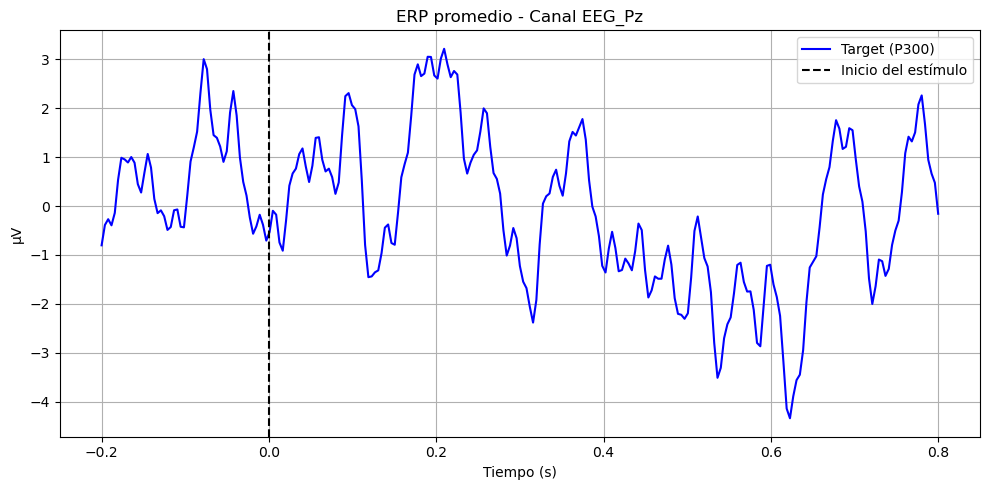

In [17]:
epochs_target = []
for t in event_indices:
    if t - pre >= 0 and t + post < len(eeg_data):
        epoch = eeg_data[t - pre : t + post]
        epochs_target.append(epoch)
epochs_target = np.array(epochs_target)

plt.figure(figsize=(10, 5))
plt.plot(times, epochs_target.mean(axis=0), label='Target (P300)', color='blue')
plt.axvline(0, color='k', linestyle='--', label='Inicio del estímulo')
plt.title(f'ERP promedio - Canal {channel}')
plt.xlabel("Tiempo (s)")
plt.ylabel("μV")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()